**Handwritten digit** recognition is a classification problem, where the goal is to correctly identify digits (0–9) from images.

**Import Libraries**

In [1]:
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt

# Load and Explore the Dataset

In [2]:
data = keras.datasets.mnist.load_data()

In [3]:
print(data[0][1].shape)
print(data[1][0].shape)

(60000,)
(10000, 28, 28)


# Data Preprocessing

In [4]:
(X_train , y_train ), (X_test , y_test) = keras.datasets.mnist.load_data()

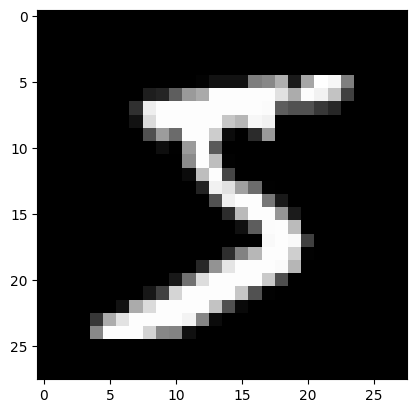

In [5]:
img = X_train[0]
plt.imshow(img , cmap = 'grey' )
plt.show()

In [6]:
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

# Model Building and training

In [7]:
from keras.models import Sequential
model = Sequential([
    keras.layers.InputLayer(shape = (28 , 28))  ,
    keras.layers.Flatten() ,
    keras.layers.Dense(128 , activation = 'relu') ,
    keras.layers.Dense(64 ,activation = 'relu' ),
    keras.layers.Dense(32 ,activation = 'relu' ),
    keras.layers.Dense(10 ,activation = 'softmax' ),
])

In [8]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 111,146 (434.16 KB)

 Trainable params: 111,146 (434.16 KB)

 Non-trainable params: 0 (0.00 B)

**The difference** between the predicted and actual output is calculated using *cross-entropy* loss:



In [9]:
model.compile(optimizer='adam' , loss = 'sparse_categorical_crossentropy' , metrics = ['accuracy'] )

In [10]:
model_history = model.fit(
    X_train , y_train , validation_split=0.1 ,
    batch_size=32 ,
    epochs=10
)

Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.8651 - loss: 0.4689 - val_accuracy: 0.9650 - val_loss: 0.1203
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9634 - loss: 0.1189 - val_accuracy: 0.9650 - val_loss: 0.1127
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9760 - loss: 0.0781 - val_accuracy: 0.9758 - val_loss: 0.0842
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9816 - loss: 0.0564 - val_accuracy: 0.9748 - val_loss: 0.0844
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9852 - loss: 0.0456 - val_accuracy: 0.9755 - val_loss: 0.0819
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9877 - loss: 0.0375 - val_accuracy: 0.9778 - val_loss: 0.0857
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9897 - loss: 0.0310 - val_accuracy: 0.9762 - val_loss: 0.0892
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9914 - loss: 0.0261 

**Leanring Curves**

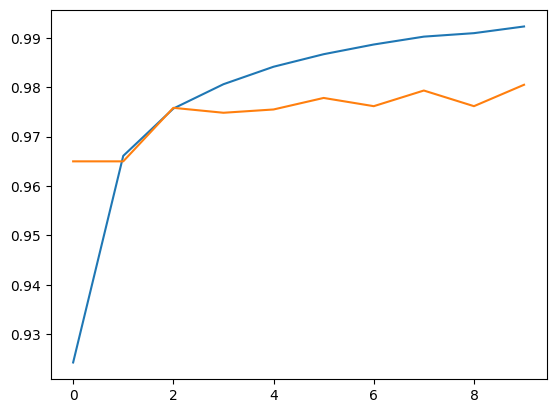

In [11]:
plt.plot(model_history.history['accuracy'] , label = 'Train acc')
plt.plot(model_history.history['val_accuracy'] , label = 'Validaiton acc')
plt.show()

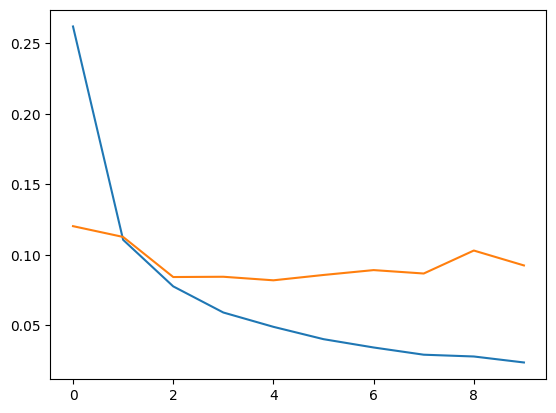

In [12]:
plt.plot(model_history.history['loss'] , label = 'Train loss')
plt.plot(model_history.history['val_loss'] , label = 'Validaiton loss')
plt.show()

# Model Evaluation

In [13]:
model.evaluate(X_test , y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9756 - loss: 0.0989


[0.08773203939199448, 0.9786999821662903]

In [14]:
prediction = model.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


In [15]:
prediction

array([[5.9768973e-10, 1.6779902e-08, 3.5492985e-08, ..., 9.9999988e-01,
        3.4374299e-11, 8.5459160e-09],
       [3.6015371e-15, 3.4096392e-11, 1.0000000e+00, ..., 3.7595093e-13,
        2.5446921e-11, 6.5083568e-19],
       [3.3604561e-08, 9.9983680e-01, 4.8650581e-06, ..., 1.0860859e-04,
        1.0940276e-05, 9.5724739e-10],
       ...,
       [2.0690163e-16, 9.5581054e-14, 1.6338578e-15, ..., 2.4856178e-10,
        4.6700006e-14, 3.6106698e-08],
       [3.6759175e-17, 1.6410519e-17, 2.7561414e-16, ..., 3.0557138e-13,
        3.4322219e-11, 1.6829720e-15],
       [3.1208564e-11, 9.9437960e-20, 3.6291441e-17, ..., 8.9896327e-22,
        8.9835840e-14, 1.9535779e-15]], dtype=float32)

In [16]:
import numpy as np

classes = np.argmax(prediction , axis = 1)

In [17]:
print(np.unique(classes,return_counts=True))

(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=int64), array([ 979, 1128, 1021, 1033,  992,  895,  957, 1039,  964,  992],
      dtype=int64))


In [18]:
from  sklearn.metrics  import classification_report , confusion_matrix
cm = confusion_matrix(y_test , classes)

In [19]:
print(cm)

[[ 971    0    1    0    0    1    3    1    3    0]
 [   0 1120    1    2    0    2    4    3    2    1]
 [   1    1 1009    9    1    0    3    6    2    0]
 [   0    0    1  996    0    4    0    4    2    3]
 [   1    0    1    0  963    0    4    3    1    9]
 [   1    0    0   15    2  866    3    1    3    1]
 [   2    2    1    1    3    7  939    0    3    0]
 [   1    3    5    1    1    0    0 1012    1    4]
 [   0    0    2    4    3   10    1    5  943    6]
 [   2    2    0    5   19    5    0    4    4  968]]


In [20]:
print(classification_report(y_test , classes , digits = 3))

              precision    recall  f1-score   support

           0      0.992     0.991     0.991       980
           1      0.993     0.987     0.990      1135
           2      0.988     0.978     0.983      1032
           3      0.964     0.986     0.975      1010
           4      0.971     0.981     0.976       982
           5      0.968     0.971     0.969       892
           6      0.981     0.980     0.981       958
           7      0.974     0.984     0.979      1028
           8      0.978     0.968     0.973       974
           9      0.976     0.959     0.968      1009

    accuracy                          0.979     10000
   macro avg      0.978     0.979     0.978     10000
weighted avg      0.979     0.979     0.979     10000

